In [ ]:
# This script fetches Bitcoin data, generates trading signals based on Dow Theory,
# and plots the signals on a chart.

from strategy.dow_theory.gen_strategy import generate_signals
from test_dow_theory import fetch_btc_data, plot_btc_signals

btc_data = fetch_btc_data()
signals = generate_signals(btc_data)
plot_btc_signals(btc_data, signals)
print(signals.tail(10))

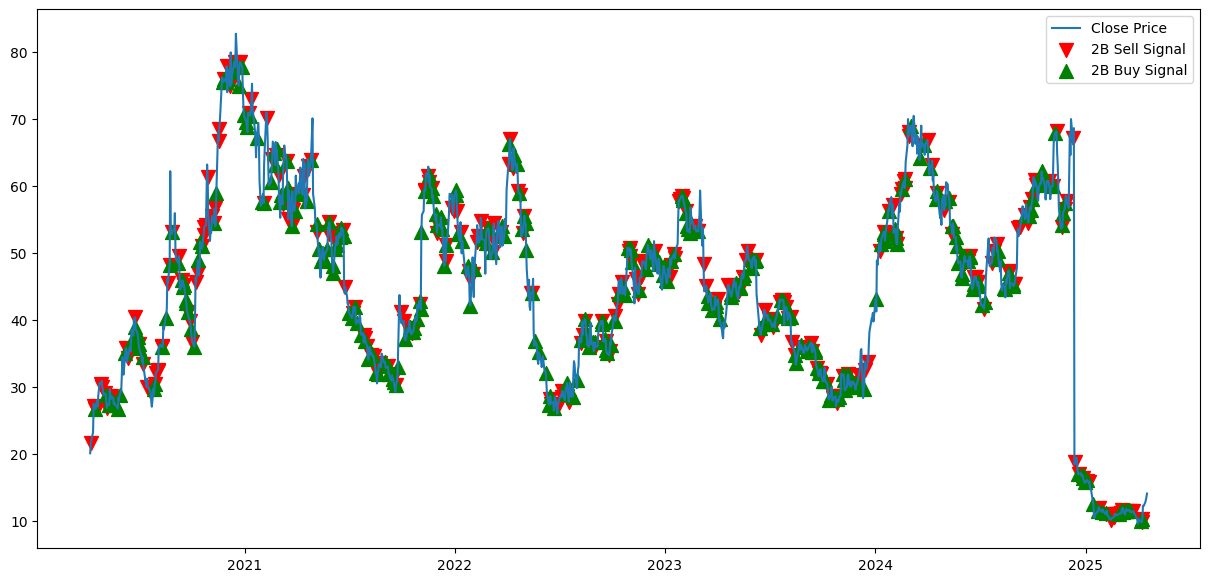

            trend_line_up  trend_line_down  buy_condition1  buy_condition2  \
date                                                                         
2025-04-04           9.41            11.94           False            True   
2025-04-07           9.37            11.94           False           False   
2025-04-08           9.37            11.94           False            True   
2025-04-09           9.12            11.94           False           False   
2025-04-10           9.12            12.50           False            True   
2025-04-11           9.12            12.50           False            True   
2025-04-14           9.12            12.90           False            True   
2025-04-15           9.12            13.19           False            True   
2025-04-16           9.12            13.58           False            True   
2025-04-17           9.12            14.20           False            True   

            buy_condition3  123_buy_signal  sell_condition1  se

In [1]:
# The following code fetches stock data for Apple Inc. (AAPL)
# and generates trading signals based on Dow Theory.

from src.io.read_data import load_stocks_data
from strategy.dow_theory.gen_strategy import generate_signals
from test_dow_theory import plot_stock_signals

df = load_stocks_data('kros', '2025-04-21')
signals = generate_signals(df)
plot_stock_signals(df, signals)
print(signals.tail(10))

In [2]:
# print(signals.columns)
print(signals[["123_buy_signal", "123_sell_signal", "2B_buy_signal", "2B_sell_signal"]].tail(10))


            123_buy_signal  123_sell_signal  2B_buy_signal  2B_sell_signal
date                                                                      
2025-04-04           False            False          False           False
2025-04-07           False            False           True           False
2025-04-08           False            False          False            True
2025-04-09           False            False           True            True
2025-04-10           False            False          False           False
2025-04-11           False            False          False           False
2025-04-14           False            False          False           False
2025-04-15           False            False          False           False
2025-04-16           False            False          False           False
2025-04-17           False            False          False           False


/data/quant_stocks/src/strategy/dow_theory/gen_strategy.py:122: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["upward_trend"] = upward_trends
/data/quant_stocks/src/strategy/dow_theory/gen_strategy.py:123: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["downward_trend"] = downward_trends


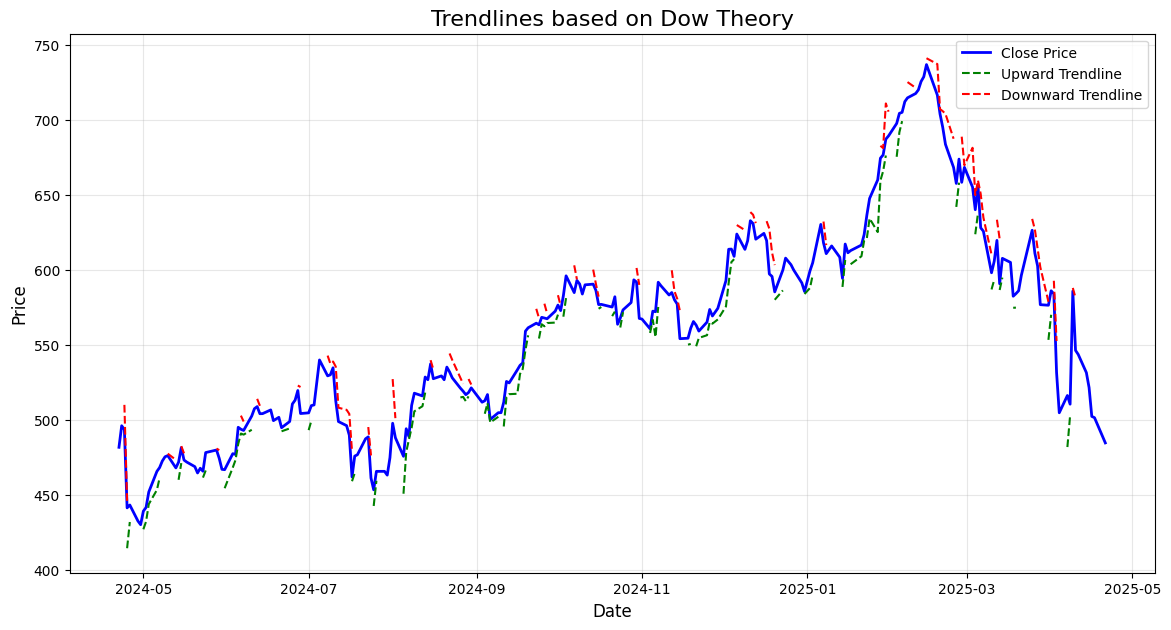

In [13]:
import pandas as pd
from src.io.read_data import load_stocks_data

from strategy.dow_theory.gen_strategy import calculate_trendlines
from test_dow_theory import plot_trendlines

df = load_stocks_data("meta", "2025-04-21")
df = calculate_trendlines(df.query("index >= '2024-04-21'"), "short")

# 绘制趋势线
plot_trendlines(df)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from src.io.read_data import load_stocks_data

# 加载数据
df = load_stocks_data("nvda", "2025-04-21")[pd.to_datetime("2024-09-21") : pd.to_datetime("2025-04-21")]
print(df.tail(10))

# 找到非 NaN 的局部极小值
troughs = (
    df[(df["close"] <= df["close"].shift(1)) & (df["close"] <= df["close"].shift(-1))]
    .dropna()
    .sort_values(by="close")
)
print(troughs)

# 确保可以通过索引提取局部极小值
start_idx = df.index.get_loc(troughs.index[0])  # 第一个局部极小值位置
end_idx = df.index.get_loc(troughs.index[-1])  # 最后一个局部极小值位置

# 提取 x 和 y 值
x_values = df.index[
    start_idx : end_idx + 1
].tolist()  # 包含终止点，+1 是因为切片是左闭右开
y_values = df["close"][start_idx : end_idx + 1].tolist()

# 计算斜率并延伸趋势线
slope = (y_values[-1] - y_values[0]) / (len(x_values) - 1) if len(x_values) > 1 else 0
trend_line = [y_values[0] + i * slope for i in range(len(x_values))]

# 绘制趋势线
plt.plot(x_values, y_values, label="Price Data")
plt.plot(x_values, trend_line, "--", label=f"Trend Line (Slope = {slope:.2f})")
plt.legend()
plt.title('Upward Trend Line According to "Professional Trading"')
plt.show()

data_dir: /data/quant_stocks/cleaned_stocks_data
加载股票数据文件: /data/quant_stocks/cleaned_stocks_data/kros.csv
           ticker   open     high      low  close   volume
date                                                      
2025-05-12   KROS  13.78  14.2400  13.4350  13.74  1222921
2025-05-13   KROS  13.59  13.7050  13.2100  13.47   537978
2025-05-14   KROS  13.57  13.7500  13.1397  13.59   624919
2025-05-15   KROS  13.66  14.0400  13.3900  14.03  1264944
2025-05-16   KROS  14.08  14.2200  13.7600  14.07   633971
2025-05-19   KROS  14.05  14.4400  13.9500  14.10   578994
2025-05-20   KROS  14.10  14.2500  13.9100  14.14   722446
2025-05-21   KROS  14.07  14.2750  13.7200  14.04   625349
2025-05-22   KROS  13.90  14.2400  13.8850  14.16   411139
2025-05-23   KROS  14.01  14.7397  14.0100  14.57   581394
2020-04-08 00:00:00 2025-05-23 00:00:00
当前持仓数量：0, 当前资金：1000000.0
当前信号：1.0，时间：2021-01-04
买入信号: 69.58, size: 18
买入完成: 18 @ 70.08 手续费: 2.5228800000000002
当前持仓数量：18, 当前资金：998736.0371200001


<IPython.core.display.Javascript object>

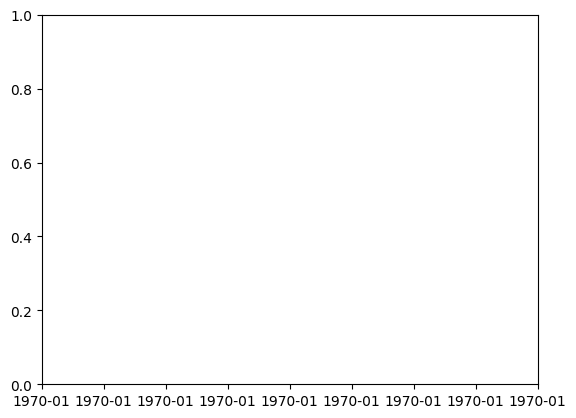

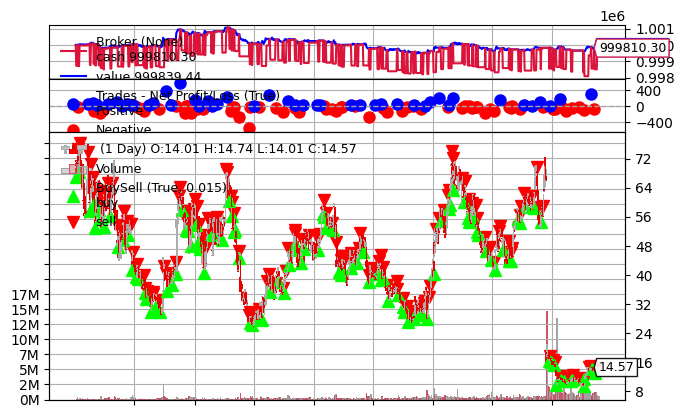

In [1]:
from datetime import datetime
import backtrader as bt
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, DateFormatter

from src.conf import STRATEGY_NAME
from src.io.read_data import load_stocks_data
from src.strategy.analyze import get_specific_strategy
from test_strategy import BacktraderStrategy, CustomPandasData

import os

data_dir = os.path.abspath(os.path.join(os.getcwd(), "../cleaned_stocks_data/"))
print("data_dir:", data_dir)

# 数据加载与处理
df = load_stocks_data(dir=data_dir, ticker="kros")
print(df.tail(10))
df = get_specific_strategy(df, STRATEGY_NAME)

cerebro = bt.Cerebro()  # 初始化回测系统

# 日期范围设置
start_date = datetime(2021, 1, 1)
end_date = datetime(2025, 5, 23)

# Backtrader 数据格式转换
data = CustomPandasData(dataname=df, fromdate=start_date, todate=end_date)

# 检查日期范围是否充分
print(df.index.min(), df.index.max())
assert start_date >= df.index.min() and end_date <= df.index.max(), "数据覆盖范围不足"

cerebro.adddata(data)  # 将数据传入回测系统
cerebro.addstrategy(BacktraderStrategy)  # 加载策略
start_cash = 1000000
cerebro.broker.setcash(start_cash)  # 设置初始资金
cerebro.broker.setcommission(commission=0.002)  # 设置手续费
cerebro.run()  # 系统回测

port_value = cerebro.broker.getvalue()  # 回测后资金
pnl = port_value - start_cash  # 盈亏分析
print(
    f"初始资金: {start_cash}\n回测期间：{start_date.strftime('%Y%m%d')}:{end_date.strftime('%Y%m%d')}"
)
print(f"总资金: {round(port_value, 2)}")
print(f"净收益: {round(pnl, 2)}")

# 绘图处理
fig, axes = plt.subplots(1, 1)  # 初始化图像
cerebro.plot(style="candlestick")

# 设置日期格式
locator = AutoDateLocator()
formatter = DateFormatter("%Y-%m")
axes.xaxis.set_major_locator(locator)
axes.xaxis.set_major_formatter(formatter)
plt.gcf().autofmt_xdate()  # 日期自动旋转

plt.show()  # 显示图像